<a href="https://colab.research.google.com/github/sfaizenn/AnalisisNumerik/blob/main/25083010009_Sandi_Fadia_Aizena_Analisis_Numerik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Sandi Fadia Aizena

NPM : 25083010009

Mata Kuliah : Analisis Numerik


### **Import library dan membaca dataset**

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Membaca dataset
df = pd.read_csv("sintesis_data_donat_harian.csv")

display(df.head())

,Tanggal,Gerai,Harga Jual (Rp),Jumlah Terjual (Unit),Pendapatan Kotor (Rp),Biaya Variabel (Rp),Fixed Cost Harian (Rp),Balance (Rp)
0,2026-01-01,Gerai A,25000,87,2175000,739500,1683333,-247833
1,2026-01-02,Gerai A,25000,81,2025000,688500,1683333,-346833
2,2026-01-03,Gerai A,25000,110,2750000,935000,1683333,131667
3,2026-01-04,Gerai A,25000,119,2975000,1011500,1683333,280167
4,2026-01-05,Gerai A,25000,94,2350000,799000,1683333,-132333


### **Plot jumlah penjualan vs revenue (per gerai)**

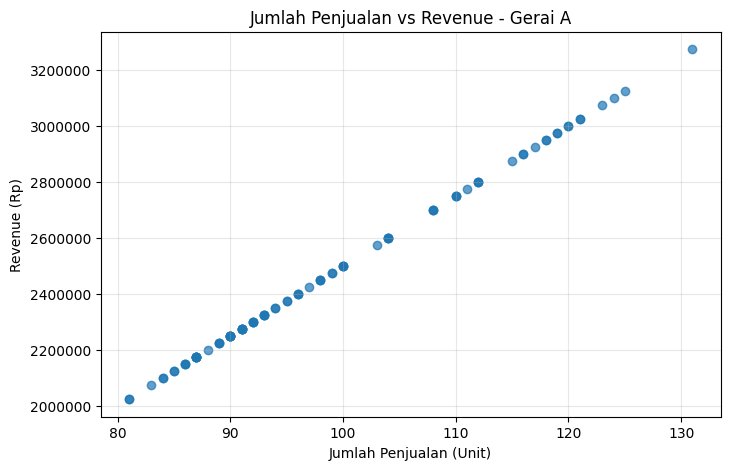

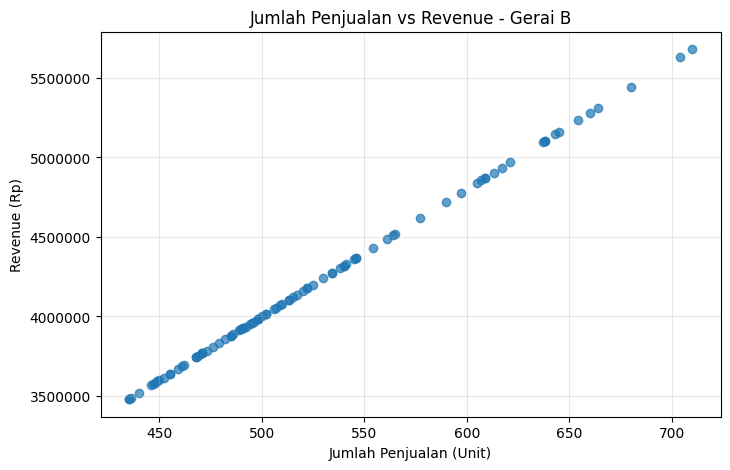

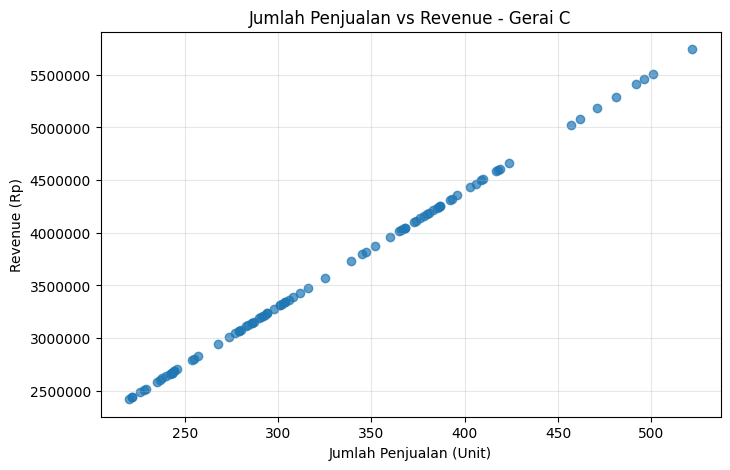

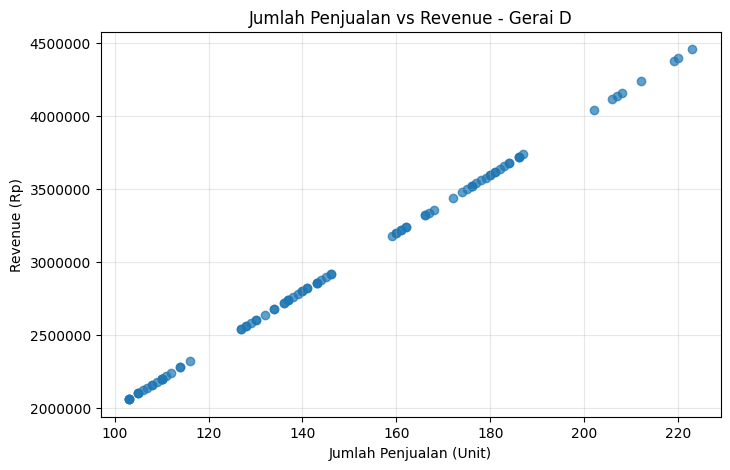

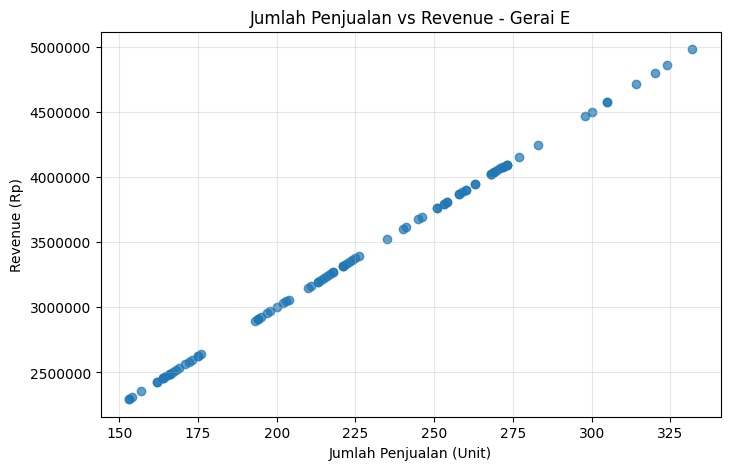

In [36]:
for gerai in sorted(df["Gerai"].unique()):
    data = df[df["Gerai"] == gerai]

    plt.figure(figsize=(8, 5))
    plt.scatter(
        data["Jumlah Terjual (Unit)"],
        data["Pendapatan Kotor (Rp)"],
        alpha=0.7
    )
    plt.title(f"Jumlah Penjualan vs Revenue - {gerai}")
    plt.xlabel("Jumlah Penjualan (Unit)")
    plt.ylabel("Revenue (Rp)")
    plt.grid(alpha=0.3)
    plt.ticklabel_format(style="plain", axis="y")
    plt.show()

### **Gabungan 5 gerai**

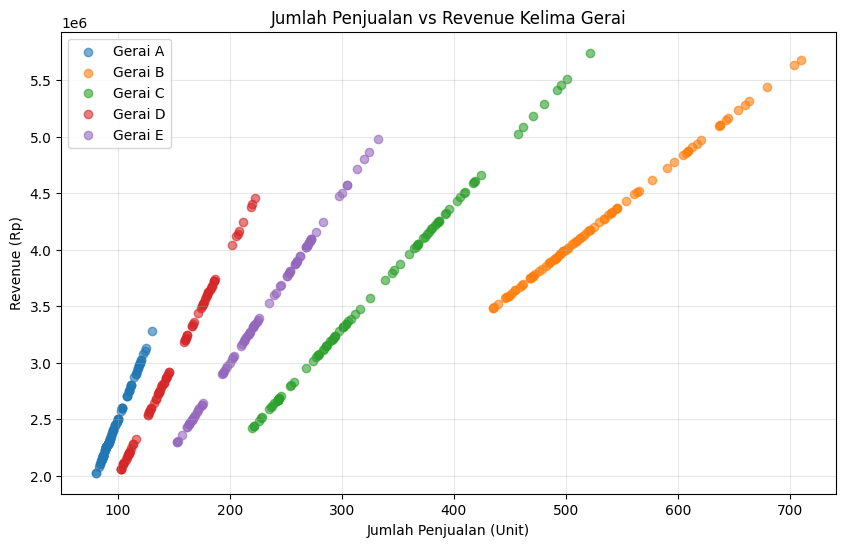

In [37]:
plt.figure(figsize=(10, 6))

for gerai in sorted(df["Gerai"].unique()):
    data = df[df["Gerai"] == gerai]
    plt.scatter(
        data["Jumlah Terjual (Unit)"],
        data["Pendapatan Kotor (Rp)"],
        alpha=0.6,
        label=gerai
    )

plt.title("Jumlah Penjualan vs Revenue Kelima Gerai")
plt.xlabel("Jumlah Penjualan (Unit)")
plt.ylabel("Revenue (Rp)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Interpretasi**

Berdasarkan grafik, kelima gerai menunjukkan pola hubungan positif antara jumlah penjualan dan revenue. Artinya, semakin banyak produk yang terjual, semakin besar pendapatan kotor yang diperoleh.Pada Gerai A, B, C, D, dan E, titik-titik data membentuk pola yang hampir lurus dan mengikuti arah yang meningkat. Hal ini menunjukkan bahwa kenaikan revenue berlangsung secara relatif konsisten seiring bertambahnya jumlah produk yang terjual.

Meskipun rentang jumlah penjualan setiap gerai berbeda, pola hubungan yang terbentuk pada kelima gerai menunjukkan bahwa volume penjualan menjadi faktor yang berkaitan langsung dengan peningkatan revenue. Pola yang cenderung linear tersebut menjadi dasar untuk menggunakan regresi linear dalam menganalisis hubungan antara jumlah penjualan dan revenue pada tahap berikutnya.

### **Regresi revenue terhadap volume penjualan (per gerai)**

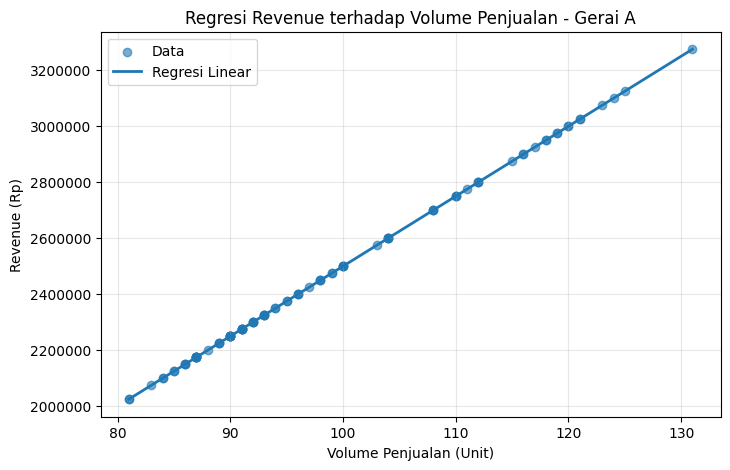

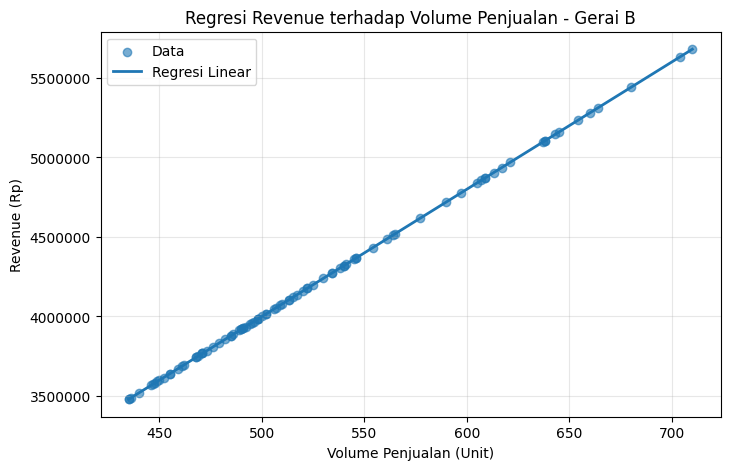

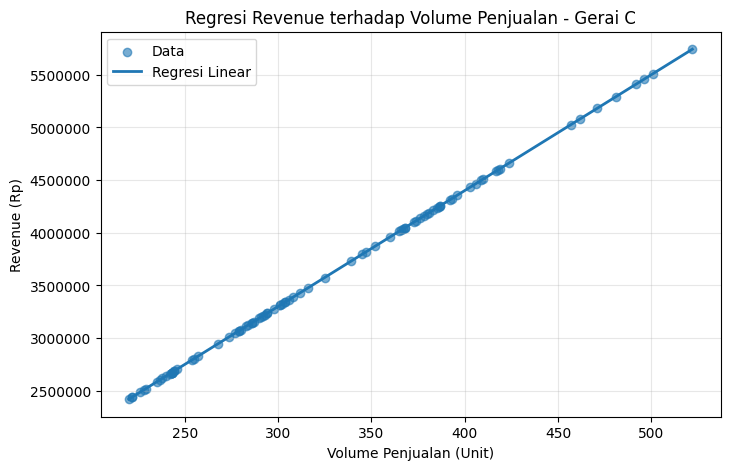

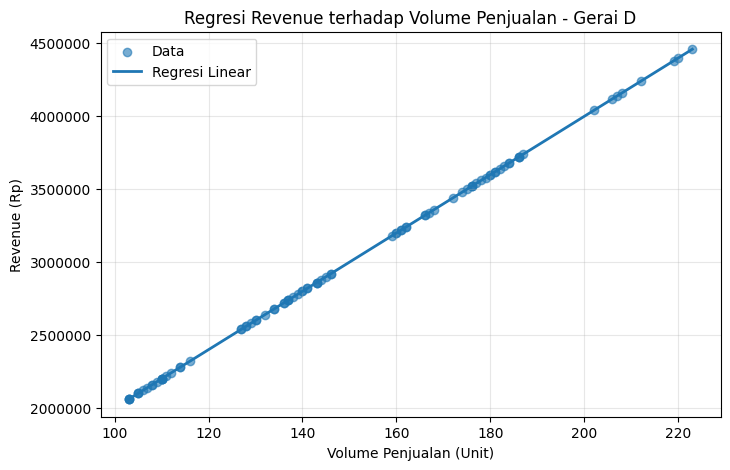

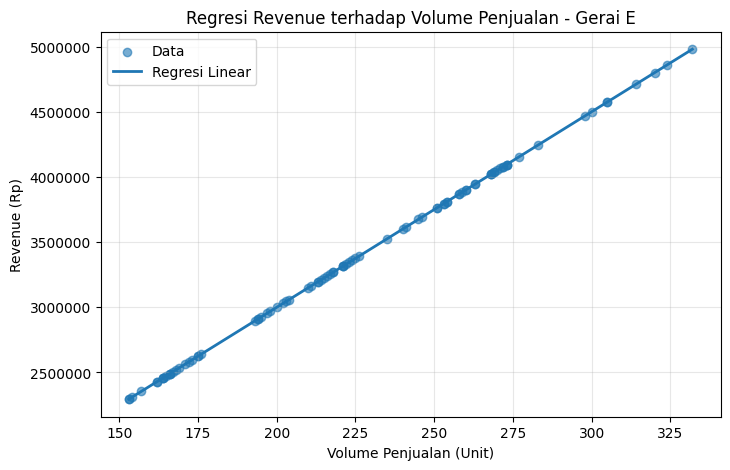

In [38]:
hasil_regresi = {}

for gerai in sorted(df["Gerai"].unique()):
    data = df[df["Gerai"] == gerai]

    x = data["Jumlah Terjual (Unit)"].to_numpy()
    y = data["Pendapatan Kotor (Rp)"].to_numpy()

    b, a = np.polyfit(x, y, 1)
    y_pred = a + b * x

    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    hasil_regresi[gerai] = {"a": a, "b": b, "r2": r2}

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = a + b * x_line

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, alpha=0.6, label="Data")
    plt.plot(x_line, y_line, linewidth=2, label="Regresi Linear")
    plt.title(f"Regresi Revenue terhadap Volume Penjualan - {gerai}")
    plt.xlabel("Volume Penjualan (Unit)")
    plt.ylabel("Revenue (Rp)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.ticklabel_format(style="plain", axis="y")
    plt.show()

### **Chart gabungan 5 gerai + garis regresi**

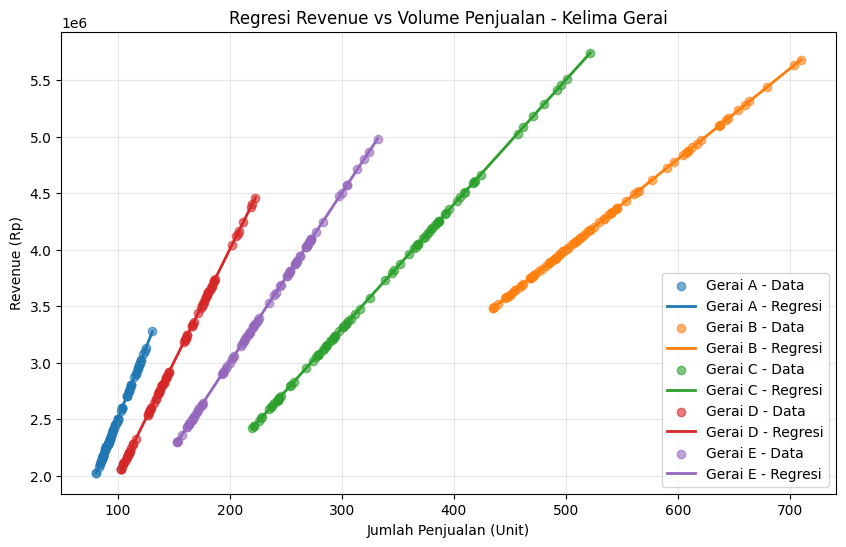

In [39]:
plt.figure(figsize=(10, 6))

for gerai in sorted(df["Gerai"].unique()):
    data = df[df["Gerai"] == gerai]
    x = data["Jumlah Terjual (Unit)"].to_numpy()
    y = data["Pendapatan Kotor (Rp)"].to_numpy()

    a = hasil_regresi[gerai]["a"]
    b = hasil_regresi[gerai]["b"]
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = a + b * x_line

    plt.scatter(x, y, alpha=0.6, label=f"{gerai} - Data")
    plt.plot(x_line, y_line, linewidth=2, label=f"{gerai} - Regresi")

plt.title("Regresi Revenue vs Volume Penjualan - Kelima Gerai")
plt.xlabel("Jumlah Penjualan (Unit)")
plt.ylabel("Revenue (Rp)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Interpretasi**

Berdasarkan grafik regresi, kelima gerai menunjukkan hubungan linear positif antara volume penjualan dan pendapatan kotor, dengan nilai R² mendekati 1.000000 pada seluruh gerai — menandakan model linear dapat menggambarkan pola hubungan kedua variabel dengan sangat baik. Besarnya peningkatan pendapatan untuk setiap tambahan satu unit penjualan berbeda pada masing-masing gerai (berkisar dari Rp8.000 hingga Rp25.000 per unit), sesuai dengan strategi harga masing-masing. Hasil ini selanjutnya digunakan sebagai model pendapatan dalam perhitungan Break Even Point (BEP).

### **Menampilkan Persamaan Regresi dan R²**

In [40]:
for gerai, hasil in hasil_regresi.items():
    print(f"{gerai}")
    print(f"Revenue = {hasil['a']:.2f} + {hasil['b']:.2f}x")
    print(f"R² = {hasil['r2']:.6f}")
    print()

Gerai A
Revenue = -0.00 + 25000.00x
R² = 1.000000

Gerai B
Revenue = -0.00 + 8000.00x
R² = 1.000000

Gerai C
Revenue = 0.00 + 11000.00x
R² = 1.000000

Gerai D
Revenue = -0.00 + 20000.00x
R² = 1.000000

Gerai E
Revenue = 0.00 + 15000.00x
R² = 1.000000



**Interpretasi**

Berdasarkan hasil regresi, seluruh gerai memiliki hubungan linear positif antara jumlah penjualan dan pendapatan kotor dengan nilai R² sebesar 1,000000. Hal ini menunjukkan bahwa pada dataset yang digunakan, perubahan pendapatan kotor dapat dijelaskan sepenuhnya oleh jumlah unit yang terjual melalui model regresi linear. Dengan demikian, model linear sesuai dengan pola data pada masing-masing gerai. Persamaan regresi menunjukkan perkiraan pertambahan pendapatan kotor untuk setiap tambahan satu unit produk yang terjual. Gerai A memiliki koefisien sebesar Rp25.000 per unit, Gerai B sebesar Rp8.000 per unit, Gerai C sebesar Rp11.000 per unit, Gerai D sebesar Rp20.000 per unit, dan Gerai E sebesar Rp15.000 per unit. Artinya, setiap tambahan satu unit penjualan akan meningkatkan pendapatan kotor sesuai dengan koefisien masing-masing gerai. Nilai konstanta pada seluruh model mendekati 0, sehingga hubungan antara jumlah penjualan dan revenue pada dataset dapat direpresentasikan secara langsung melalui koefisien per unit tersebut. Hasil regresi ini selanjutnya digunakan sebagai fungsi pendapatan dalam perhitungan Break Even Point (BEP).

### **Perbandingan Model Alternatif (Validasi Pemilihan Bentuk Regresi)**

In [41]:
from scipy.optimize import curve_fit

def fungsi_eksponensial(x, a, b):
    return a * np.exp(b * x)

perbandingan_model = []

for gerai in sorted(df["Gerai"].unique()):
    data = df[df["Gerai"] == gerai]
    x = data["Jumlah Terjual (Unit)"].to_numpy()
    y = data["Pendapatan Kotor (Rp)"].to_numpy()

    ss_tot = np.sum((y - y.mean()) ** 2)

    b1, a1 = np.polyfit(x, y, 1)
    r2_linear = 1 - np.sum((y - (a1 + b1 * x)) ** 2) / ss_tot

    c2, b2, a2 = np.polyfit(x, y, 2)
    r2_kuadratik = 1 - np.sum((y - (a2 + b2 * x + c2 * x**2)) ** 2) / ss_tot

    try:
        popt, _ = curve_fit(
            fungsi_eksponensial, x, y,
            p0=[max(y.min(), 1), 0.001],
            bounds=([0, -1], [np.inf, 1]),
            maxfev=10000
        )
        r2_eksponensial = 1 - np.sum((y - fungsi_eksponensial(x, *popt)) ** 2) / ss_tot
    except RuntimeError:
        r2_eksponensial = np.nan

    perbandingan_model.append([gerai, r2_linear, r2_kuadratik, r2_eksponensial])

df_perbandingan = pd.DataFrame(
    perbandingan_model,
    columns=["Gerai", "R2_Linear", "R2_Kuadratik", "R2_Eksponensial"]
)
display(df_perbandingan)

,Gerai,R2_Linear,R2_Kuadratik,R2_Eksponensial
0,Gerai A,1.0,1.0,0.996948
1,Gerai B,1.0,1.0,0.995829
2,Gerai C,1.0,1.0,0.985904
3,Gerai D,1.0,1.0,0.988177
4,Gerai E,1.0,1.0,0.988725


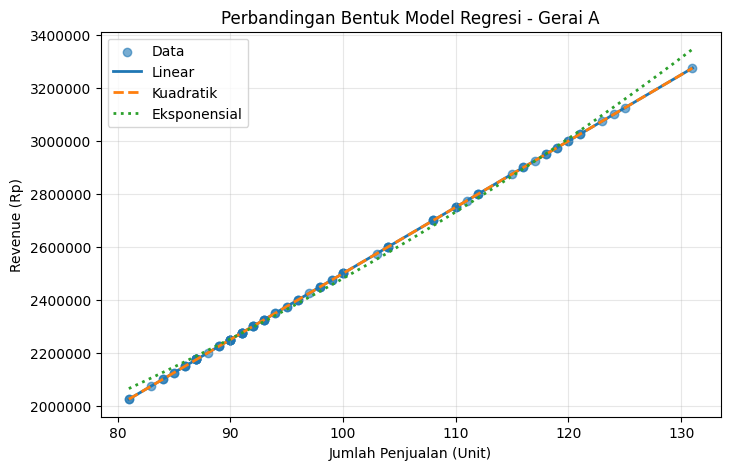

In [42]:
gerai_contoh = sorted(df["Gerai"].unique())[0]
data = df[df["Gerai"] == gerai_contoh]
x = data["Jumlah Terjual (Unit)"].to_numpy()
y = data["Pendapatan Kotor (Rp)"].to_numpy()
x_line = np.linspace(x.min(), x.max(), 200)

b1, a1 = np.polyfit(x, y, 1)
c2, b2, a2 = np.polyfit(x, y, 2)
popt, _ = curve_fit(fungsi_eksponensial, x, y, p0=[max(y.min(), 1), 0.001], maxfev=10000)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6, label="Data")
plt.plot(x_line, a1 + b1 * x_line, label="Linear", linewidth=2)
plt.plot(x_line, a2 + b2 * x_line + c2 * x_line**2, label="Kuadratik", linewidth=2, linestyle="--")
plt.plot(x_line, fungsi_eksponensial(x_line, *popt), label="Eksponensial", linewidth=2, linestyle=":")
plt.title(f"Perbandingan Bentuk Model Regresi - {gerai_contoh}")
plt.xlabel("Jumlah Penjualan (Unit)")
plt.ylabel("Revenue (Rp)")
plt.legend()
plt.grid(alpha=0.3)
plt.ticklabel_format(style="plain", axis="y")
plt.show()

**Interpretasi**

Hasil perbandingan menunjukkan bahwa model linear dan kuadratik sama-sama menghasilkan R² = 1,000000 pada seluruh gerai, sedangkan model eksponensial justru memberikan R² yang lebih rendah (berkisar 0,985–0,997). Karena model kuadratik memiliki parameter tambahan namun tidak memberikan peningkatan R² sama sekali dibanding linear, tambahan kompleksitas tersebut tidak memberikan manfaat apa pun terhadap ketepatan model. Sementara itu, model eksponensial justru kurang sesuai dibanding kedua model lainnya untuk seluruh gerai.

Berdasarkan hasil ini, model linear tetap dipilih sebagai model terbaik untuk merepresentasikan hubungan revenue terhadap volume penjualan, berdasarkan prinsip parsimoni (Ockham's Razor): model paling sederhana yang sudah mampu menjelaskan data secara sempurna. Dengan demikian, penggunaan model linear pada tahap regresi sebelumnya sudah tepat dan terbukti secara kuantitatif, bukan hanya berdasarkan inspeksi visual.

### **Membentuk Model untuk BEP**

In [43]:
model_bep = {}

for gerai in sorted(df["Gerai"].unique()):

    data = df[df["Gerai"] == gerai]

    x = data["Jumlah Terjual (Unit)"].to_numpy()

    # Mengambil hasil regresi revenue dari poin 2
    a_revenue = hasil_regresi[gerai]["a"]
    b_revenue = hasil_regresi[gerai]["b"]

    # Membentuk model biaya variabel
    y_variable = data["Biaya Variabel (Rp)"].to_numpy()

    b_variable, a_variable = np.polyfit(
      x,
      y_variable,
      1
    )

    # Fixed cost
    fixed_cost = data["Fixed Cost Harian (Rp)"].iloc[0]

    model_bep[gerai] = {
        "a_revenue": a_revenue,
        "b_revenue": b_revenue,
        "a_variable": a_variable,
        "b_variable": b_variable,
        "fixed_cost": fixed_cost
    }


# Menampilkan model biaya yang digunakan
for gerai, model in model_bep.items():

    print(f"{gerai}")
    print(
        f"Revenue = {model['a_revenue']:.2f} + "
        f"{model['b_revenue']:.2f}x"
    )
    print(
        f"Biaya Variabel = {model['a_variable']:.2f} + "
        f"{model['b_variable']:.2f}x"
    )
    print(
        f"Fixed Cost = Rp{model['fixed_cost']:,.0f}"
    )
    print()

Gerai A
Revenue = -0.00 + 25000.00x
Biaya Variabel = -0.00 + 8500.00x
Fixed Cost = Rp1,683,333

Gerai B
Revenue = -0.00 + 8000.00x
Biaya Variabel = -0.00 + 4160.00x
Fixed Cost = Rp733,333

Gerai C
Revenue = 0.00 + 11000.00x
Biaya Variabel = -0.00 + 4840.00x
Fixed Cost = Rp1,733,333

Gerai D
Revenue = -0.00 + 20000.00x
Biaya Variabel = -0.00 + 7200.00x
Fixed Cost = Rp2,666,666

Gerai E
Revenue = 0.00 + 15000.00x
Biaya Variabel = 0.00 + 6300.00x
Fixed Cost = Rp800,000



**Interpretasi**

Hasil pemodelan menunjukkan bahwa setiap gerai memiliki karakteristik biaya yang berbeda. Biaya variabel per unit sebesar Rp8.500 pada Gerai A, Rp4.160 pada Gerai B, Rp4.840 pada Gerai C, Rp7.200 pada Gerai D, dan Rp6.300 pada Gerai E. Artinya, setiap tambahan satu unit produk yang terjual akan menambah biaya variabel sesuai dengan nilai tersebut. Selain biaya variabel, setiap gerai juga memiliki fixed cost harian yang harus ditanggung meskipun jumlah penjualan berubah. Gerai D memiliki fixed cost terbesar, yaitu Rp2.666.666, sedangkan Gerai E memiliki fixed cost sebesar Rp800.000.

Perbedaan biaya variabel dan fixed cost tersebut menyebabkan jumlah penjualan yang dibutuhkan setiap gerai untuk mencapai BEP menjadi berbeda. Model revenue, biaya variabel, dan fixed cost ini selanjutnya digunakan untuk membentuk fungsi profit. Fungsi tersebut menjadi dasar dalam metode Bisection untuk mencari jumlah penjualan saat profit bernilai nol atau mencapai titik impas.

### **Membuat Fungsi Profit**

Fungsi profit digunakan untuk menghitung keuntungan berdasarkan jumlah unit yang terjual. Profit diperoleh dari selisih antara revenue dan total biaya, dengan total biaya terdiri dari biaya variabel dan fixed cost. Fungsi ini kemudian digunakan pada metode Bisection untuk mencari jumlah penjualan saat profit bernilai nol atau mencapai BEP.

In [44]:
def fungsi_bep(x, model):

    revenue = (
        model["a_revenue"]
        + model["b_revenue"] * x
    )

    biaya_variabel = (
        model["a_variable"]
        + model["b_variable"] * x
    )

    total_cost = (
        biaya_variabel
        + model["fixed_cost"]
    )

    profit = revenue - total_cost

    return profit

### **Metode Bisection**

Metode Bisection digunakan untuk mencari akar dari fungsi profit, yaitu nilai volume penjualan saat profit bernilai nol. Metode ini bekerja dengan membagi interval menjadi dua bagian secara berulang hingga diperoleh nilai akar dengan tingkat ketelitian yang ditentukan.

In [45]:
def bisection(f, a, b, tol=1e-6, max_iter=100):

    fa = f(a)
    fb = f(b)

    # Memastikan interval mengurung akar
    if fa * fb > 0:
        raise ValueError(
            "Interval awal tidak mengurung akar."
        )

    for i in range(max_iter):

        c = (a + b) / 2
        fc = f(c)

        # Kondisi berhenti
        if abs(fc) < tol or abs(b - a) < tol:
            return c, i + 1

        # Menentukan interval berikutnya
        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc

    return c, max_iter

### **Mencari BEP Kelima Gerai**

In [46]:
hasil_bep = []

for gerai, model in model_bep.items():

    # Fungsi profit untuk gerai
    f = lambda x, model=model: fungsi_bep(x, model)

    # Interval awal
    a = 0
    b = 1

    # Mencari batas atas sampai terjadi perubahan tanda
    while f(a) * f(b) > 0:
        b *= 2

    # Mencari akar menggunakan Bisection
    akar, iterasi = bisection(
        f,
        a,
        b
    )

    # Karena volume penjualan berupa unit,
    # dibulatkan ke atas
    bep_minimum = int(np.ceil(akar))

    hasil_bep.append([
        gerai,
        akar,
        bep_minimum,
        iterasi
    ])


hasil_bep_df = pd.DataFrame(
    hasil_bep,
    columns=[
        "Gerai",
        "BEP Numerik (Unit)",
        "BEP Minimum (Unit)",
        "Jumlah Iterasi"
    ]
)

display(hasil_bep_df)

,Gerai,BEP Numerik (Unit),BEP Minimum (Unit),Jumlah Iterasi
0,Gerai A,102.020182,103,28
1,Gerai B,190.972135,191,29
2,Gerai C,281.385228,282,30
3,Gerai D,208.333281,209,29
4,Gerai E,91.954023,92,28


**Interpretasi Hasil BEP**

Berdasarkan hasil perhitungan menggunakan metode Bisection, diperoleh jumlah penjualan saat profit mencapai nol untuk masing-masing gerai. Gerai A memiliki BEP sebesar 102,02 unit, Gerai B sebesar 190,97 unit, Gerai C sebesar 281,39 unit, Gerai D sebesar 208,33 unit, dan Gerai E sebesar 91,95 unit. Hasil tersebut menunjukkan bahwa setiap gerai memiliki kebutuhan volume penjualan yang berbeda untuk mencapai kondisi impas. Perbedaan ini dipengaruhi oleh revenue per unit, biaya variabel per unit, dan fixed cost yang telah dimodelkan sebelumnya.

Nilai BEP yang lebih tinggi menunjukkan bahwa gerai membutuhkan volume penjualan yang lebih besar untuk menutup seluruh biaya yang dikeluarkan. Karena jumlah produk yang terjual harus berupa bilangan bulat, hasil BEP numerik dibulatkan ke atas menjadi BEP minimum. Dengan demikian, Gerai A membutuhkan minimal 103 unit, Gerai B 191 unit, Gerai C 282 unit, Gerai D 209 unit, dan Gerai E 92 unit untuk mencapai atau melewati titik impas berdasarkan model yang digunakan. Metode Bisection memperoleh hasil tersebut dalam 28–30 iterasi.

### **Kesimpulan**

Berdasarkan analisis yang telah dilakukan, hubungan antara jumlah penjualan dan revenue pada kelima gerai menunjukkan pola linear positif. Hasil regresi memiliki nilai R² sebesar 1,000000 pada seluruh gerai, sehingga model linear dapat menggambarkan hubungan antara jumlah penjualan dan revenue pada dataset dengan sangat baik. Pemilihan model linear juga telah divalidasi melalui perbandingan dengan model kuadratik dan eksponensial. Model kuadratik tidak memberikan peningkatan R² dibandingkan model linear, sedangkan model eksponensial menghasilkan nilai R² yang lebih rendah. Dengan demikian, model linear digunakan sebagai model pendapatan pada analisis selanjutnya.

Berdasarkan model pendapatan dan biaya yang diperoleh, metode Bisection berhasil menemukan titik BEP untuk masing-masing gerai. BEP minimum yang diperoleh adalah 103 unit untuk Gerai A, 191 unit untuk Gerai B, 282 unit untuk Gerai C, 209 unit untuk Gerai D, dan 92 unit untuk Gerai E. Perbedaan nilai BEP antar gerai dipengaruhi oleh kombinasi revenue per unit, biaya variabel per unit, dan fixed cost harian masing-masing gerai.

Secara keseluruhan, hasil analisis menunjukkan bahwa metode numerik berupa regresi dapat digunakan untuk memodelkan hubungan antara volume penjualan dan revenue, sedangkan metode Bisection dapat digunakan untuk mencari akar fungsi profit dalam menentukan titik BEP. Hasil tersebut dapat digunakan untuk mengetahui jumlah penjualan minimum yang dibutuhkan setiap gerai untuk mencapai titik impas.